In [3]:
import pandas as pd

df = pd.read_csv("../data/processed/forecast_features.csv")
print(df.columns.tolist())


['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city', 'state', 'type_x', 'cluster', 'transactions', 'type_y', 'locale', 'locale_name', 'description', 'transferred', 'year', 'month', 'day', 'day_of_week', 'week_of_year', 'quarter', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'promotion_flag', 'promotion_ratio', 'holiday_locale', 'holiday_locale_name', 'holiday_description', 'holiday_transferred', 'is_holiday', 'holiday_type_Additional', 'holiday_type_Bridge', 'holiday_type_Event', 'holiday_type_Holiday', 'holiday_type_Transfer', 'holiday_type_Work Day', 'holiday_type_nan', 'store_avg_sales', 'family_avg_sales']


📊 Visualization: Sales vs Lag

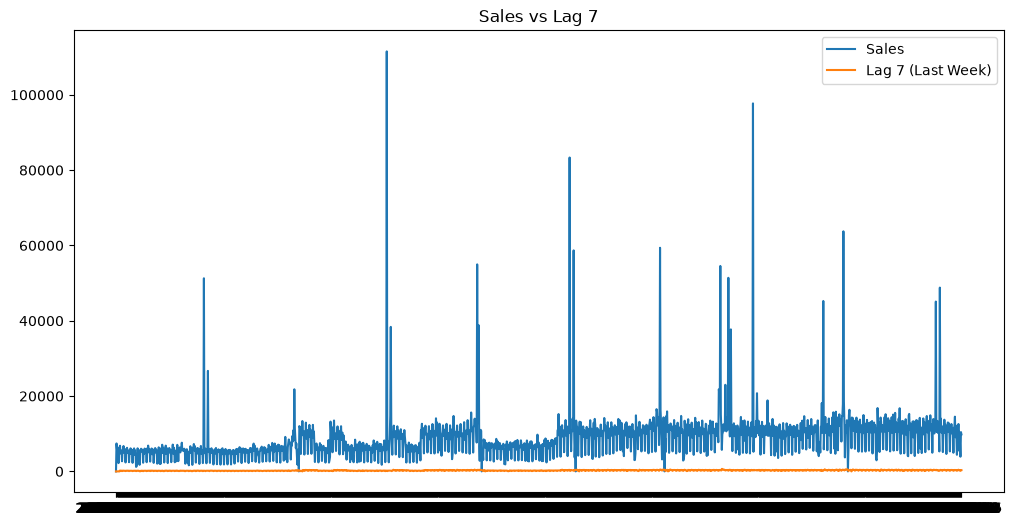

In [4]:
import matplotlib.pyplot as plt

sample = df[df["store_nbr"] == 1].groupby("date").agg({"sales":"sum","lag_7":"mean"})

plt.figure(figsize=(12,6))
plt.plot(sample.index, sample["sales"], label="Sales")
plt.plot(sample.index, sample["lag_7"], label="Lag 7 (Last Week)")
plt.legend()
plt.title("Sales vs Lag 7")
plt.show()


📊 Visualization: Rolling Averages

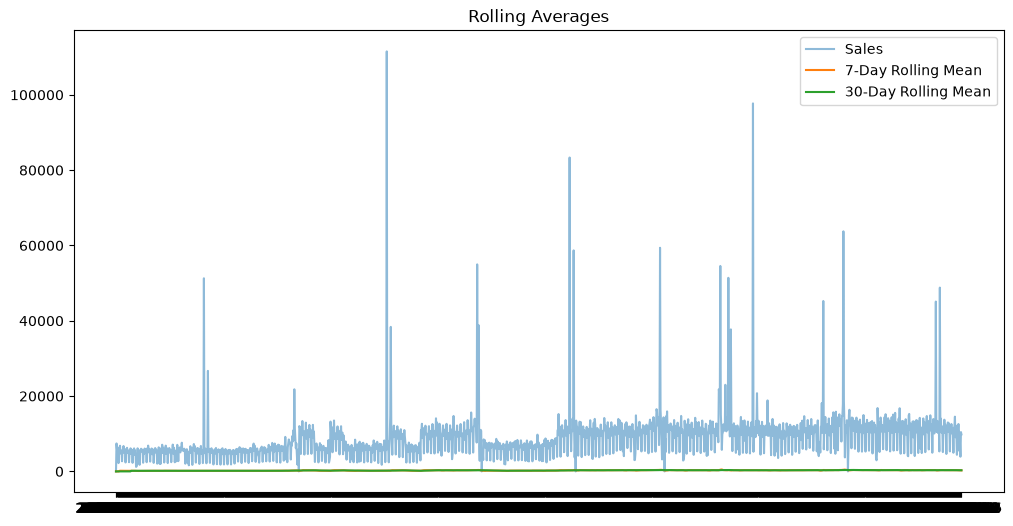

In [5]:
sample = df[df["store_nbr"] == 1].groupby("date").agg({
    "sales":"sum",
    "rolling_mean_7":"mean",
    "rolling_mean_30":"mean"
})

plt.figure(figsize=(12,6))
plt.plot(sample.index, sample["sales"], alpha=0.5, label="Sales")
plt.plot(sample.index, sample["rolling_mean_7"], label="7‑Day Rolling Mean")
plt.plot(sample.index, sample["rolling_mean_30"], label="30‑Day Rolling Mean")
plt.legend()
plt.title("Rolling Averages")
plt.show()


📊 Visualization: Monthly Seasonality

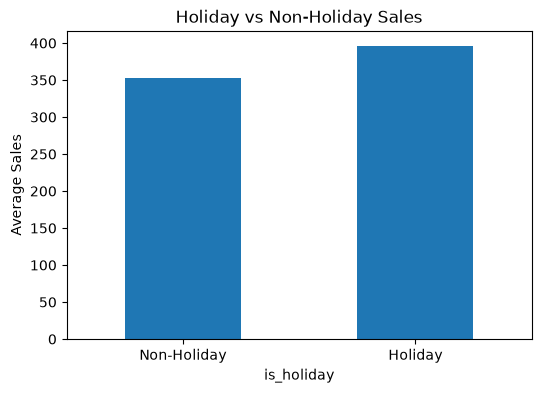

In [6]:
holiday_sales = df.groupby("is_holiday")["sales"].mean()

plt.figure(figsize=(6,4))
holiday_sales.plot(kind="bar")
plt.title("Holiday vs Non‑Holiday Sales")
plt.xticks([0,1], ["Non‑Holiday","Holiday"], rotation=0)
plt.ylabel("Average Sales")
plt.show()


📊 Visualization: Promotion Impact

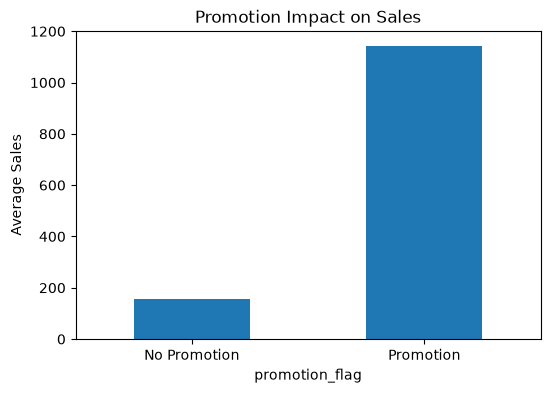

In [7]:
promo_sales = df.groupby("promotion_flag")["sales"].mean()

plt.figure(figsize=(6,4))
promo_sales.plot(kind="bar")
plt.title("Promotion Impact on Sales")
plt.xticks([0,1], ["No Promotion","Promotion"], rotation=0)
plt.ylabel("Average Sales")
plt.show()
